In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import joblib

## 1. Loading Dataset

In [269]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Customer-Churn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [270]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [271]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Performing Exploratory Data Analysis(EDA)



In [272]:
# it return total uniques values and its count
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [273]:
# Checking Percentage
df["Churn"].value_counts(normalize=True).mul(100)

,proportion
Churn,
No,73.463013
Yes,26.536987


In [274]:
# finding relationship between contract and churn, how it behave on different contract period
pd.crosstab(df["Contract"], df["Churn"], normalize="index").mul(100)

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [275]:
pd.crosstab(
    pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72]),
    df["Churn"],
    normalize="index"
).mul(100)

Churn,No,Yes
tenure,,
"(-1, 12]",52.561757,47.438243
"(12, 24]",71.289062,28.710938
"(24, 48]",79.611041,20.388959
"(48, 72]",90.486824,9.513176


Through All the below codes we are checking the relationship between churn and different feature(or column) in our dataset and finding how much each columns has impact on the churn and decide the most important feature

In [276]:
# we can see here higher monthly charges more likely to churn first group all no and yes then take their mean median
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


In [277]:
# What's the average tenure of each churn group means how long churned stay and how long not churned stay their average
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [278]:
# For each payment method, what percentage of customers churned?
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").mul(100)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [279]:
# For each internet Service (DSL, optic Fibre,No), what percentage of customers churned?
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").mul(100)

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [280]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index").mul(100)

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


# Data Cleaning

In [281]:
# type of total charge is in string so we need to convert to number
type(df["TotalCharges"].iloc[0])

str

In [282]:
# here some of the rows of total charge are empty means they are very new customer did not complete their tenure so they didn't make any payment yet that's why empty
df[df["TotalCharges"].str.strip() == ""].shape

(11, 21)

In [283]:
df["TotalCharges"] = df["TotalCharges"].astype(str).str.strip()

print("Blank TotalCharges:", (df["TotalCharges"] == "").sum())
print("Missing values before cleaning:")
print(df.isna().sum().sum())

Blank TotalCharges: 11
Missing values before cleaning:
0


In [284]:
df = df[df["TotalCharges"] != ""].copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique customer IDs:", df["customerID"].nunique())

Shape after cleaning: (7032, 21)
Missing values after cleaning: 0
Duplicate rows: 0
Unique customer IDs: 7032


In [285]:
df = df.drop(columns="customerID")

## 4. Train/Test Split



In [286]:
X = df.drop(columns="Churn")
y = df["Churn"]


In [287]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42, # For reproducibility
    stratify=y # proportion remain same of yes and no in both train and test
)

In [288]:
# converts text labels ("Yes" and "No") into binary numbers (1 and 0)
y_test_binary = (y_test == "Yes").astype(int)

In [289]:
print("Training:", X_train.shape, y_train.shape)
print("Testing :", X_test.shape, y_test.shape)

Training: (5625, 19) (5625,)
Testing : (1407, 19) (1407,)


In [290]:
# Verifying Stratify
print("Train target distribution:")
print(y_train.value_counts(normalize=True).mul(100))

Train target distribution:
Churn
No     73.422222
Yes    26.577778
Name: proportion, dtype: float64


In [291]:

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100))


Test target distribution:
Churn
No     73.418621
Yes    26.581379
Name: proportion, dtype: float64


## 5. Preprocessing

Now we convert categorical column into numerical value as model only understand numerical data, So start the actual preprocessing/encoding

In [292]:
# Check which columns are categorical, This will show us all categorical columns
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [293]:
# This will show us all numerical columns.
X.select_dtypes(exclude="object").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [294]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]



In [295]:
# here we scale numerical column by standardscaler and on categorical we apply one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 6. Baseline: Logistic Regression

Logistic Regression is our first model because it is simple, fast, and interpretable.

In [296]:
# Preprocess the training data
X_train_processed = preprocessor.fit_transform(X_train)

In [297]:
# After preprocessing, It have 45 columns because One-Hot Encoding increases the number of features.
print(X_train_processed.shape)

(5625, 45)


In [298]:
# making pipeline first it gets preprocessed then LR model apply on it
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [299]:
#Training
lr_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [300]:
#Testing
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1] #this gives exact probability and above label to 1 or 0 based on prob and threshold

In [301]:
# How many we predict right
print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.8038379530916845


In [302]:
# On predicting churn, how many actually churn
print("Precision:", precision_score(y_test, lr_pred, pos_label="Yes"))

Precision: 0.6484848484848484


In [303]:
# Out of all churn, how many we identify
print("Recall:", recall_score(y_test, lr_pred, pos_label="Yes"))


Recall: 0.5721925133689839


In [304]:
# balancing both precision and recall
print("F1:", f1_score(y_test, lr_pred, pos_label="Yes"))

F1: 0.6079545454545454


In [305]:
# How much we correctly identify churn and no churn
print("ROC-AUC:", roc_auc_score(y_test_binary, lr_prob))

ROC-AUC: 0.8359290473207676


In [306]:
#                   Predicted
#                  No      Yes

# Actual No       TN       FP
# Actual Yes      FN       TP
print("\nConfusion matrix:")
print(confusion_matrix(y_test, lr_pred))


Confusion matrix:
[[917 116]
 [160 214]]


In [307]:
print("Classification report:")
print(classification_report(y_test, lr_pred))

Classification report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 7. Logistic Regression Interpretation





In [308]:
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
#feature_names

In [309]:
coefficients = lr_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

Model Interpretation see what model learns from feature and how it uses those feature to predict churn,coefficient gives each feature contribution

+ → pushes the prediction toward Churn = Yes
- → pushes the prediction toward Churn = No

In [310]:
# Let's see the strongest positive coefficients:These are the features that the model is using most strongly toward churn.
# That would also make sense relative to the EDA we did earlier Month-to-month churn ≈ 42.7% and we can see here
print("The coefficients show the direction of the model's learned relationship with churn.\n")
coef_df.sort_values("Coefficient", ascending=False).head(10)

The coefficients show the direction of the model's learned relationship with churn.



,Feature,Coefficient
3,num__TotalCharges,0.644014
36,cat__Contract_Month-to-month,0.613846
16,cat__InternetService_Fiber optic,0.590184
32,cat__StreamingTV_Yes,0.191113
43,cat__PaymentMethod_Electronic check,0.180671
35,cat__StreamingMovies_Yes,0.177076
18,cat__OnlineSecurity_No,0.164459
27,cat__TechSupport_No,0.142949
14,cat__MultipleLines_Yes,0.088164
0,num__SeniorCitizen,0.071011


In [311]:
# These are the strongest features pushing away from churn
coef_df.sort_values("Coefficient").head(10)

,Feature,Coefficient
1,num__tenure,-1.352313
38,cat__Contract_Two year,-0.779030
15,cat__InternetService_DSL,-0.616132
2,num__MonthlyCharges,-0.541006
39,cat__PaperlessBilling_No,-0.300387
12,cat__MultipleLines_No,-0.293470
25,cat__DeviceProtection_No internet service,-0.283724
22,cat__OnlineBackup_No internet service,-0.283724
31,cat__StreamingTV_No internet service,-0.283724
28,cat__TechSupport_No internet service,-0.283724


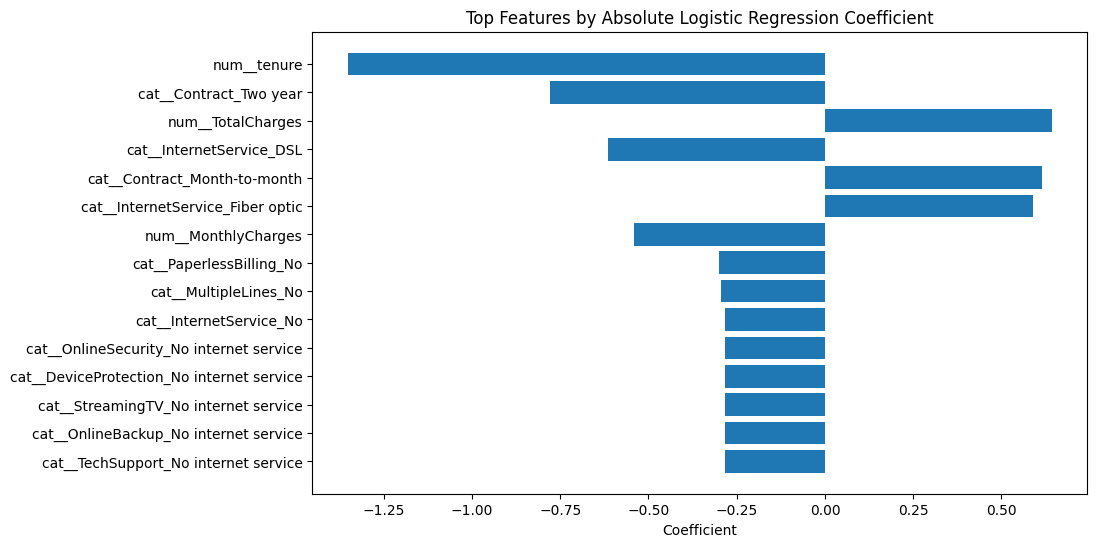

In [312]:
top_features = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Features by Absolute Logistic Regression Coefficient")
plt.gca().invert_yaxis()
plt.show()

## 8. Model Comparison

We try, Random Forest and XGBoost to determine whether nonlinear tree-based models can capture non-linear raltionship between features if exist and improve on the Logistic Regression baseline.



In [313]:
# Random Forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In a Random Forest model, setting class_weight="balanced" automatically adjusts the importance of each class during training to correct for heavily imbalanced datasets.
Instead of treating every data point equally, it forces the algorithm to pay closer attention to minority classes, preventing the model from becoming biased toward the majority class.

In [314]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [315]:
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [316]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.7839374555792467


In [317]:
print("Precision:", precision_score(y_test, rf_pred, pos_label="Yes"))


Precision: 0.6223776223776224


In [318]:
print("Recall:", recall_score(y_test, rf_pred, pos_label="Yes"))


Recall: 0.47593582887700536


In [319]:
print("F1:", f1_score(y_test, rf_pred, pos_label="Yes"))


F1: 0.5393939393939394


In [320]:
print("ROC-AUC:", roc_auc_score(y_test_binary, rf_prob))

ROC-AUC: 0.8116176858845271


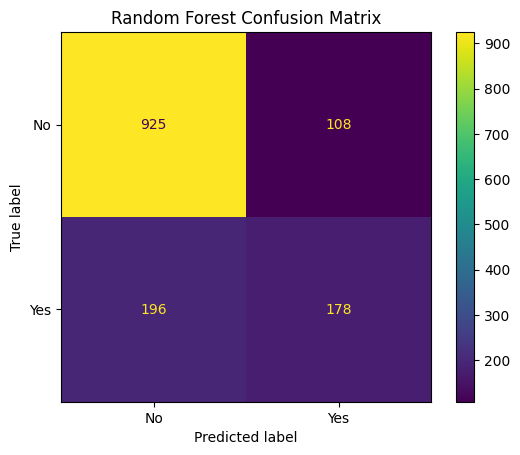

In [321]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [322]:
# Xgboost
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [323]:
xgb_pipeline.fit(X_train, (y_train == "Yes").astype(int))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'Streamin...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [324]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [325]:
print("Accuracy:", accuracy_score(y_test_binary, xgb_pred))


Accuracy: 0.7889125799573561


In [326]:
print("Precision:", precision_score(y_test_binary, xgb_pred))


Precision: 0.6237942122186495


In [327]:
print("Recall:", recall_score(y_test_binary, xgb_pred))


Recall: 0.5187165775401069


In [328]:
print("F1:", f1_score(y_test_binary, xgb_pred))


F1: 0.5664233576642336


In [329]:
print("ROC-AUC:", roc_auc_score(y_test_binary, xgb_prob))

ROC-AUC: 0.8357918631678669


In [330]:
print(confusion_matrix(y_test_binary,xgb_pred))

[[916 117]
 [180 194]]


### Cross-validated model comparison

Before choosing a final model, compare the candidates using the training data only. This gives us a model-selection signal without using the held-out test set.

In [331]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [332]:
y_train_binary = (y_train == "Yes").astype(int)

In [333]:
model_candidates = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [334]:
cv_results = []

for name, pipeline in model_candidates.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train_binary,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_model_df = pd.DataFrame(cv_results).sort_values(
    "CV F1 Mean",
    ascending=False
)

cv_model_df

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.595262,0.022889
2,XGBoost,0.582824,0.019273
1,Random Forest,0.559714,0.020872


## 9. Class Imbalance Experiment

The dataset has fewer churners than non-churners. We test class weighting to see how changing the training objective affects churn recall and precision.

In [335]:
lr_balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

In [336]:
lr_balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [337]:
lr_balanced_pred = lr_balanced_pipeline.predict(X_test)
lr_balanced_prob = lr_balanced_pipeline.predict_proba(X_test)[:, 1]

In [338]:
# Balanced Logistic Regression
print("Accuracy:", accuracy_score(y_test, lr_balanced_pred))

Accuracy: 0.7256574271499645


In [339]:
print("Precision:", precision_score(y_test, lr_balanced_pred, pos_label="Yes"))

Precision: 0.4901315789473684


In [340]:
print("Recall:", recall_score(y_test, lr_balanced_pred, pos_label="Yes"))

Recall: 0.7967914438502673


In [341]:
print("F1:", f1_score(y_test, lr_balanced_pred, pos_label="Yes"))

F1: 0.6069246435845214


In [342]:
print("ROC-AUC:", roc_auc_score(y_test_binary, lr_balanced_prob))

ROC-AUC: 0.8351344145860403


## 10. XGBoost Hyperparameter Tuning

Now Hyperparameters tuning using 5-fold stratified cross-validation on the training data.

We do this preprocessing is inside the pipeline, so each CV fold learns preprocessing only from its training portion.

In [343]:
xgb_for_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [344]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__min_child_weight": [1, 3],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

In [345]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [346]:
grid_search.fit(X_train, (y_train == "Yes").astype(int))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'Internet...
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [3, 4, 5],
                         'model__min_child_weight': [1, 3],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8]},
             scoring='f1', verbose=1)

In [347]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best CV F1:
0.590452381480808


## 11. Out-of-Fold Threshold Selection

Now we try different threshold of hypertuned xgboost model.

In [348]:
best_xgb = grid_search.best_estimator_
y_train_binary = (y_train == "Yes").astype(int)

xgb_oof_prob = cross_val_predict(
    best_xgb,
    X_train,
    y_train_binary,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [349]:
thresholds = np.arange(0.20, 0.81, 0.05)
threshold_results = []

for threshold in thresholds:
    pred = (xgb_oof_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train_binary, pred),
        "Recall": recall_score(y_train_binary, pred),
        "F1": f1_score(y_train_binary, pred)
    })

xgb_threshold_df = pd.DataFrame(threshold_results)
xgb_threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.488399,0.858863,0.622696
1,0.25,0.517888,0.813378,0.632839
2,0.30,0.547368,0.765217,0.638215
3,0.35,0.572752,0.703010,0.631231
4,0.40,0.603362,0.648161,0.624960
5,0.45,0.634713,0.584615,0.608635
6,0.50,0.670918,0.527759,0.590790
7,0.55,0.687936,0.461538,0.552442
8,0.60,0.706235,0.393980,0.505796
9,0.65,0.758779,0.332441,0.462326


In [350]:
xgb_threshold_df.loc[xgb_threshold_df["F1"].idxmax()]

,2
Threshold,0.300000
Precision,0.547368
Recall,0.765217
F1,0.638215


## 12. Select the Final Candidate LR threshold using cross-validation



In [351]:
lr_final_candidate = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [352]:
lr_oof_prob = cross_val_predict(
    lr_final_candidate,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [353]:
lr_threshold_results = []

for threshold in thresholds:
    pred = np.where(lr_oof_prob >= threshold, "Yes", "No")
    lr_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, pred, pos_label="Yes"),
        "Recall": recall_score(y_train, pred, pos_label="Yes"),
        "F1": f1_score(y_train, pred, pos_label="Yes")
    })

lr_threshold_df = pd.DataFrame(lr_threshold_results)
lr_threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.475248,0.866890,0.613927
1,0.25,0.508794,0.812709,0.625805
2,0.30,0.541844,0.766555,0.634903
3,0.35,0.565103,0.717057,0.632075
4,0.40,0.592058,0.658194,0.623377
5,0.45,0.611757,0.598662,0.605139
6,0.50,0.653600,0.546488,0.595264
7,0.55,0.681775,0.482943,0.565388
8,0.60,0.708333,0.397993,0.509636
9,0.65,0.763819,0.305017,0.435946


In [354]:
best_lr_threshold = lr_threshold_df.loc[
    lr_threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Selected threshold:", best_lr_threshold)

Selected threshold: 0.3


In [355]:
preprocessor = lr_final_candidate.named_steps["preprocessor"]
model = lr_final_candidate.named_steps["model"]

In [356]:
# This is done for SHAP
background_raw = X_train.sample(100, random_state=42) # we select 100 customer data from train as a reference for SHAP remember each have 19 feature only
background = preprocessor.transform(background_raw) #we send it to the preprocessing to transform as our model know 45 features

## 13. Final Test Evaluation

After deciding final model and threshold. Now the test set is used for the final evaluation.

In [357]:
lr_final_candidate.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [358]:
final_test_prob = lr_final_candidate.predict_proba(X_test)[:, 1]

final_test_pred = np.where(
    final_test_prob >= best_lr_threshold,
    "Yes",
    "No"
)

In [359]:
print("Accuracy:", accuracy_score(y_test, final_test_pred))

Accuracy: 0.7427149964463398


In [360]:
print("Precision:", precision_score(y_test, final_test_pred, pos_label="Yes"))

Precision: 0.5107913669064749


In [361]:
print("Recall:", recall_score(y_test, final_test_pred, pos_label="Yes"))

Recall: 0.7593582887700535


In [362]:
print("F1:", f1_score(y_test, final_test_pred, pos_label="Yes"))

F1: 0.610752688172043


In [363]:
print("ROC-AUC:", roc_auc_score(y_test_binary, final_test_prob))

ROC-AUC: 0.8359290473207676


In [364]:
print("\nClassification report:")
print(classification_report(y_test, final_test_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_test_pred))


Classification report:
              precision    recall  f1-score   support

          No       0.89      0.74      0.81      1033
         Yes       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407


Confusion matrix:
[[761 272]
 [ 90 284]]


## 14. Saving Final Model


In [365]:
final_artifact = {
    "pipeline": lr_final_candidate,
    "threshold": float(best_lr_threshold),
    "background": background
}

joblib.dump(final_artifact, "customer_churn_model.pkl")

print("Saved: customer_churn_model.pkl")

Saved: customer_churn_model.pkl


In [366]:
from google.colab import drive
import shutil

shutil.copy(
    "customer_churn_model.pkl",
    "/content/drive/MyDrive/customer_churn_model.pkl"
)

print("Copied to Google Drive")

Copied to Google Drive


In [367]:
!pip install shap -q

In [368]:
import shap

In [369]:
preprocessor = lr_final_candidate.named_steps["preprocessor"]
lr_model = lr_final_candidate.named_steps["model"]

In [370]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [371]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'

In [372]:
explainer = shap.LinearExplainer(
    lr_model,
    X_train_transformed
)

In [373]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [374]:
print(shap_values.shape)

(1407, 45)


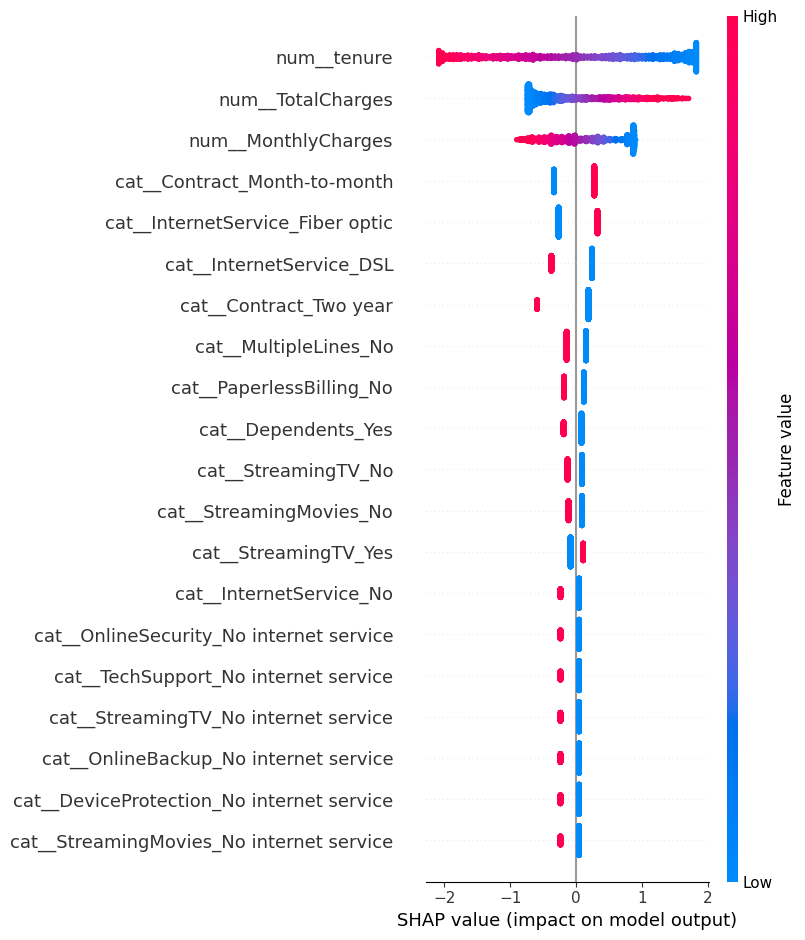

In [375]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [376]:
final_lr_prob = lr_final_candidate.predict_proba(X_test)[:, 1]

final_lr_pred = np.where(
    final_lr_prob >= best_lr_threshold,
    "Yes",
    "No"
)

In [377]:
customer_idx = np.argmax(final_lr_prob)

print("Test row:", customer_idx)
print("Actual:", y_test.iloc[customer_idx])
print("Churn probability:", final_lr_prob[customer_idx])
print("Prediction:", final_lr_pred[customer_idx])

Test row: 1149
Actual: Yes
Churn probability: 0.8474657995951387
Prediction: Yes


In [378]:
X_test.iloc[customer_idx]

,3380
gender,Male
SeniorCitizen,1
Partner,Yes
Dependents,No
tenure,1
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,No
OnlineBackup,No


In [379]:
customer_data = np.asarray(
    X_test_transformed[customer_idx]
).flatten()

customer_shap = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=customer_data,
    feature_names=feature_names
)

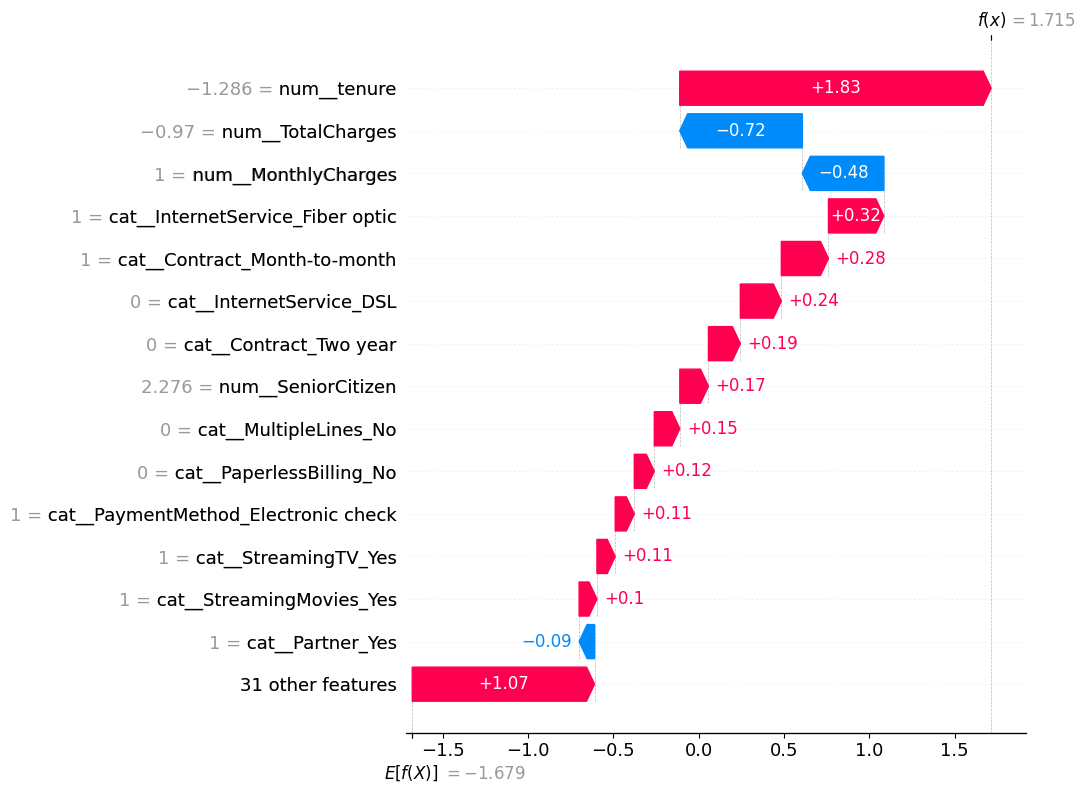

In [380]:
shap.plots.waterfall(
    customer_shap,
    max_display=15
)